Import library

In [3]:
import pandas as pd

Read the dataset of Student_habits_Performance 

In [10]:
path=r"D:\ALL\Datasets\student_habits_performance.csv"  
df=pd.read_csv(path)
print(df.columns)
print(f"SHAPE:"'\n',df.shape)

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')
SHAPE:
 (1000, 16)


Datatypes 

In [ ]:
print(df.dtypes)

student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object


Mysql connection library

In [12]:
import mysql.connector

-- MYSQL connection--

In [ ]:
conn=mysql.connector.connect(host="localhost",user="root",password=" ")
if conn:
    print("connection success")
else:
    print("connection error")    

connection success


Cursor for query execution

In [15]:
cursor=conn.cursor()

-- Database creation --

In [17]:
database_creation=("create database if not exists students")
cursor.execute(database_creation)
print("Database created")   

Database created


--Database use-- 

In [18]:
use_database=("use students")
cursor.execute(use_database)

-- Table creation--

In [20]:
table_creation="""create table if not exists students_details(
student_id                      varchar(10) primary key,
age                             int,
gender                          varchar(10),
study_hours_per_day             float,
social_media_hours              float,
netflix_hours                   float,
part_time_job                   varchar(10),
attendance_percentage           float,
sleep_hours                     float,
diet_quality                    varchar(10),
exercise_frequency              int,
parental_education_level        varchar(20),
internet_quality                varchar(10),      
mental_health_rating            int,
extracurricular_participation   varchar(10),
exam_score                      float  )"""

cursor.execute(table_creation)
print("Table created")

Table created


-- Check the table-- Fetchall

In [24]:
check_table=("Describe students_details")
columns=cursor.fetchall()
cursor.execute(check_table)
for i in columns:
    print(i)
    

('student_id', 'varchar(10)', 'NO', 'PRI', None, '')
('age', 'int', 'YES', '', None, '')
('gender', 'varchar(10)', 'YES', '', None, '')
('study_hours_per_day', 'float', 'YES', '', None, '')
('social_media_hours', 'float', 'YES', '', None, '')
('netflix_hours', 'float', 'YES', '', None, '')
('part_time_job', 'varchar(10)', 'YES', '', None, '')
('attendance_percentage', 'float', 'YES', '', None, '')
('sleep_hours', 'float', 'YES', '', None, '')
('diet_quality', 'varchar(10)', 'YES', '', None, '')
('exercise_frequency', 'int', 'YES', '', None, '')
('parental_education_level', 'varchar(20)', 'YES', '', None, '')
('internet_quality', 'varchar(10)', 'YES', '', None, '')
('mental_health_rating', 'int', 'YES', '', None, '')
('extracurricular_participation', 'varchar(10)', 'YES', '', None, '')
('exam_score', 'float', 'YES', '', None, '')


Select the dataset columns and values (csv)

In [27]:
insert_columns=",".join(df.columns)
initialize_values=",".join(["%s"]*len(df.columns)) 

-- Data insert--

In [ ]:
insert_data=f"insert into students_details({insert_columns}) values({initialize_values})"
insert_values=[tuple(x) for x in df.values]
fetch=cursor.fetchall()

cursor.executemany(insert_data,insert_values)
conn.commit()
print("Data inserted")

Data inserted


Check data insert if proper

In [45]:
check_data=("select * from students_details")
fetch_data=cursor.fetchall()
cursor.execute(check_data)


for i in fetch_data:
    print(i)    

('S1000', 23, 'Female', 0.0, 1.2, 1.1, 'No', 85.0, 8.0, 'Fair', 6, 'Master', 'Average', 8, 'Yes', 56.2)
('S1001', 20, 'Female', 6.9, 2.8, 2.3, 'No', 97.3, 4.6, 'Good', 6, 'High School', 'Average', 8, 'No', 100.0)
('S1002', 21, 'Male', 1.4, 3.1, 1.3, 'No', 94.8, 8.0, 'Poor', 1, 'High School', 'Poor', 1, 'No', 34.3)
('S1003', 23, 'Female', 1.0, 3.9, 1.0, 'No', 71.0, 9.2, 'Poor', 4, 'Master', 'Good', 1, 'Yes', 26.8)
('S1004', 19, 'Female', 5.0, 4.4, 0.5, 'No', 90.9, 4.9, 'Fair', 3, 'Master', 'Good', 1, 'No', 66.4)
('S1005', 24, 'Male', 7.2, 1.3, 0.0, 'No', 82.9, 7.4, 'Fair', 1, 'Master', 'Average', 4, 'No', 100.0)
('S1006', 21, 'Female', 5.6, 1.5, 1.4, 'Yes', 85.8, 6.5, 'Good', 2, 'Master', 'Poor', 4, 'No', 89.8)
('S1007', 21, 'Female', 4.3, 1.0, 2.0, 'Yes', 77.7, 4.6, 'Fair', 0, 'Bachelor', 'Average', 8, 'No', 72.6)
('S1008', 23, 'Female', 4.4, 2.2, 1.7, 'No', 100.0, 7.1, 'Good', 3, 'Bachelor', 'Good', 1, 'No', 78.9)
('S1009', 18, 'Female', 4.8, 3.1, 1.3, 'No', 95.4, 7.5, 'Good', 5, 'Bac

-- Query to retrive data--

In [76]:
query1="""  select  student_id,age, gender, attendance_percentage, exam_score from students_details
            where attendance_percentage > 80  and age>21
            order by exam_score desc 
            limit 10 """
            

query1_data=cursor.fetchall()
cursor.execute(query1)

for i in query1_data:
    print(i)

('S1335', 24, 'Male', 100.0, 100.0)
('S1005', 24, 'Male', 82.9, 100.0)
('S1349', 23, 'Female', 89.2, 100.0)
('S1222', 22, 'Male', 83.2, 100.0)
('S1437', 24, 'Female', 84.3, 100.0)
('S1569', 23, 'Male', 93.4, 100.0)
('S1334', 22, 'Female', 97.9, 100.0)
('S1219', 23, 'Female', 84.9, 100.0)
('S1381', 22, 'Female', 82.8, 100.0)
('S1250', 22, 'Male', 81.3, 100.0)


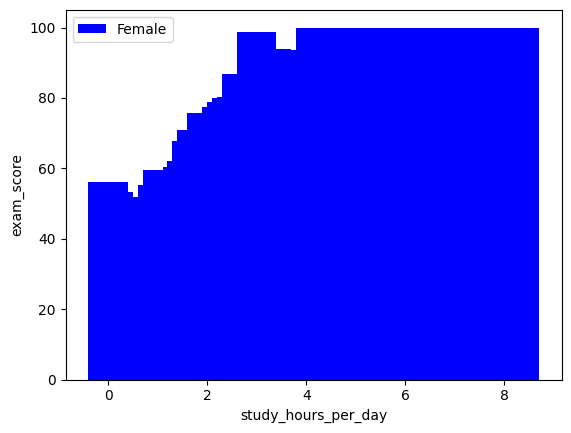

In [88]:
import matplotlib.pyplot as plt
plt.bar(df["study_hours_per_day"],df["exam_score"],color="blue",label="study_hours_per_day")
plt.xlabel("study_hours_per_day")
plt.ylabel("exam_score")
plt.legend(df["gender"])
plt.show()